### Part 1 - AURA Archiving

AURA uses zip files to reduce the inode usage (number of files), however this creates some problems for users...

AURA zip files can be very large, sometimes exceeding 5 GB/radar/day for level 1 and level 1b files. QPE products also use daily zip files.

This means they take some time to unzip locally and require lots of disk space when unzipping many files.

This tutorial will work through some practical ways to deal with this.

Let's first start by defining a small (15MB) test dataset from AURA

In [11]:
import os
from glob import glob
import tempfile
import requests
import zipfile
from datetime import datetime

import pyart

base_url = 'https://thredds.nci.org.au/thredds/fileServer/rq0/' #base url for level 1 datasets
radar_id = 50 #radar id for the desired radar
date_str = '20141127' #date in YYYYMMDD format
start_time_str = '0700' #start date in HHMM format
end_time_str = '0800' #end date in HHMM format

# parse and define file path
start_dt     = datetime.strptime(f'{date_str}_{start_time_str}', '%Y%m%d_%H%M')
end_dt       = datetime.strptime(f'{date_str}_{end_time_str}', '%Y%m%d_%H%M')
base_url     = 'https://thredds.nci.org.au/thredds/fileServer/rq0/' #base url for NCI level 1 dataset
zip_fn       = f'{radar_id}_{start_dt.strftime("%Y%m%d")}.pvol.zip'
request_url  = '/'.join([base_url, str(radar_id), start_dt.strftime('%Y'), 'vol', zip_fn])

#this is the path of the file to download (approx 15 MB zip file located on NCI THREDDS server)
print(f'Request URL: {request_url}')

#backup datafile in case of download issues
#request_url = 'https://monash-radar-workshop-2025.s3.ap-southeast-2.amazonaws.com/50_20141127.pvol.zip'

Request URL: https://thredds.nci.org.au/thredds/fileServer/rq0//50/2014/vol/50_20141127.pvol.zip


Since we're working locally, or on colab, we'll need to download this zip file to our machine.

If you're running this code on NCI (and using the direct path for level 1 data: /g/data/rq0/level_1), then you can skip this.

To download data we need a helper function that can handle very large files.

In [13]:
def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:  # filter out keep-alive chunks
                f.write(chunk)
    
    print(f"Successfully downloaded {local_filename}")
    return local_filename

temp_dir = tempfile.mkdtemp()
local_zip_filename = f'{temp_dir}/{zip_fn}'
download_file(request_url, local_zip_filename)


Successfully downloaded /tmp/tmpuo1e4ex_/50_20141127.pvol.zip


'/tmp/tmpuo1e4ex_/50_20141127.pvol.zip'

Now we can check what's inside the zip file without actually opening it (very useful for partial extraction)

In [14]:
def list_zip_contents(zip_path):
    """
    List contents of zip file (metadata only, no extraction).
    """
    if not os.path.exists(zip_path):
        raise FileNotFoundError(zip_path)

    with zipfile.ZipFile(zip_path, "r") as zf:
        file_list = sorted(zf.namelist())
    return file_list

volume_file_list = list_zip_contents(local_zip_filename)
print('\n'.join(volume_file_list))

50_20141127_000152.pvol.h5
50_20141127_001152.pvol.h5
50_20141127_002152.pvol.h5
50_20141127_003152.pvol.h5
50_20141127_004152.pvol.h5
50_20141127_005152.pvol.h5
50_20141127_010152.pvol.h5
50_20141127_011152.pvol.h5
50_20141127_012152.pvol.h5
50_20141127_013152.pvol.h5
50_20141127_014152.pvol.h5
50_20141127_015152.pvol.h5
50_20141127_020152.pvol.h5
50_20141127_021152.pvol.h5
50_20141127_022152.pvol.h5
50_20141127_023152.pvol.h5
50_20141127_024152.pvol.h5
50_20141127_025152.pvol.h5
50_20141127_030152.pvol.h5
50_20141127_031152.pvol.h5
50_20141127_032152.pvol.h5
50_20141127_033152.pvol.h5
50_20141127_034152.pvol.h5
50_20141127_035152.pvol.h5
50_20141127_040152.pvol.h5
50_20141127_041152.pvol.h5
50_20141127_042152.pvol.h5
50_20141127_043152.pvol.h5
50_20141127_044152.pvol.h5
50_20141127_045152.pvol.h5
50_20141127_050152.pvol.h5
50_20141127_051152.pvol.h5
50_20141127_052152.pvol.h5
50_20141127_053152.pvol.h5
50_20141127_054152.pvol.h5
50_20141127_055152.pvol.h5
50_20141127_060152.pvol.h5
5

Ok, let's say we only want to extract and use a small submit of this data between the start and end time

In [15]:
def extract_file_from_zip(zip_path, member, extract_path):
    """
    Extract a specific file from a zip archive.
    """
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract(member, path=extract_path)
    return None

def get_date_from_filename(filename, delimiter='_', date_fmt='%Y%m%d_%H%M%S'):
    """Extract date from a radar volume filename."""
    fn = os.path.basename(filename)
    fn_parts = fn.split(delimiter)
    
    # Reconstruct datetime string from parts[1] and parts[2] (without extension)
    dtstr = f"{fn_parts[1]}_{fn_parts[2].split('.')[0]}"
    
    return datetime.strptime(dtstr, date_fmt)

for filename in volume_file_list:
    dt = get_date_from_filename(filename)
    if start_dt <= dt <= end_dt:
        extract_file_from_zip(local_zip_filename, filename, temp_dir)

local_volume_list = sorted(glob(temp_dir + '/*.h5'))

print('\n'.join(local_volume_list))

/tmp/tmpuo1e4ex_/50_20141127_070152.pvol.h5
/tmp/tmpuo1e4ex_/50_20141127_071152.pvol.h5
/tmp/tmpuo1e4ex_/50_20141127_072152.pvol.h5
/tmp/tmpuo1e4ex_/50_20141127_073152.pvol.h5
/tmp/tmpuo1e4ex_/50_20141127_074152.pvol.h5
/tmp/tmpuo1e4ex_/50_20141127_075152.pvol.h5


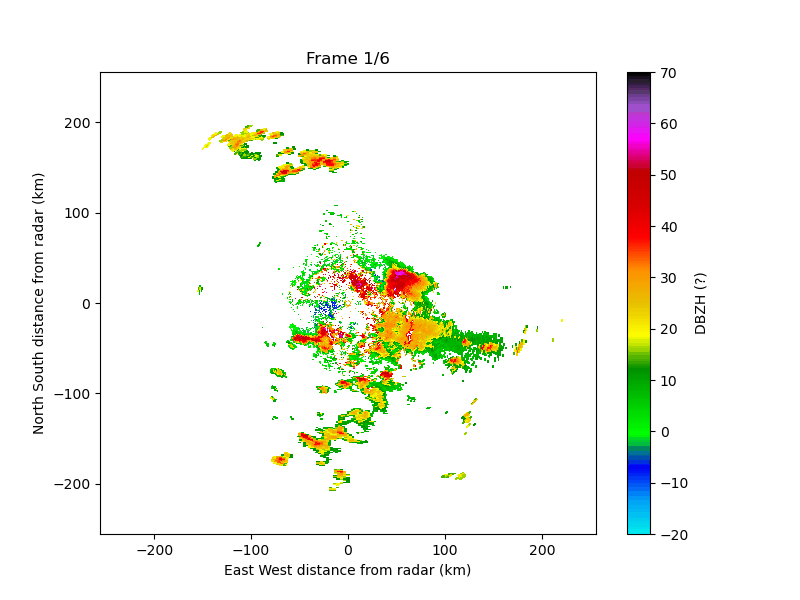

In [19]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pyart
from IPython.display import Image

radars = [pyart.aux_io.read_odim_h5(f, file_field_names=True) for f in local_volume_list]

# Create figure
fig = plt.figure(figsize=(8, 6))

def update(frame):
    plt.clf()  # Clear the figure
    
    # Create display and plot PPI
    display = pyart.graph.RadarDisplay(radars[frame])
    display.plot_ppi('DBZH', sweep=0, vmin=-20, vmax=70, 
                     cmap='NWSRef')
    
    plt.title(f'Frame {frame + 1}/{len(radars)}')

# Create animation
anim = animation.FuncAnimation(fig, update, frames=len(radars), 
                               interval=500, repeat=True)

# Save 
anim.save('/tmp/radar_animation.gif', writer='pillow', fps=2)
plt.close(fig)
# Display as HTML5 video
Image(filename='/tmp/radar_animation.gif')

You can also get the zip of each file without extracting it. This is very useful if you want to pick the most "busy" volume for a day of ML training etc.

In [16]:
file_name_list = []
file_size_list = []
with zipfile.ZipFile(local_zip_filename, 'r') as zf:
    for info in zf.infolist():
        file_name_list.append(info.filename)
        file_size_list.append(info.file_size)

max_idx = file_size_list.index(max(file_size_list))
print(f"Largest file: {file_name_list[max_idx]} with size {file_size_list[max_idx]/1000} KB")

sorted_idxs = sorted(range(len(file_size_list)), key=lambda k: file_size_list[k], reverse=True)
print("Top 5 largest files:")
for idx in sorted_idxs[:5]:
    print(f"{file_name_list[idx]} - {file_size_list[idx]/1000} KB")

Largest file: 50_20141127_083152.pvol.h5 with size 363.578 KB
Top 5 largest files:
50_20141127_083152.pvol.h5 - 363.578 KB
50_20141127_084152.pvol.h5 - 361.704 KB
50_20141127_082152.pvol.h5 - 360.584 KB
50_20141127_085152.pvol.h5 - 359.33 KB
50_20141127_081152.pvol.h5 - 356.875 KB


When you want to unpack many/all files and process them, the time to write the files to local storage can signficantly slow down your code. It's much faster to just load them directly into memory and read them from there!

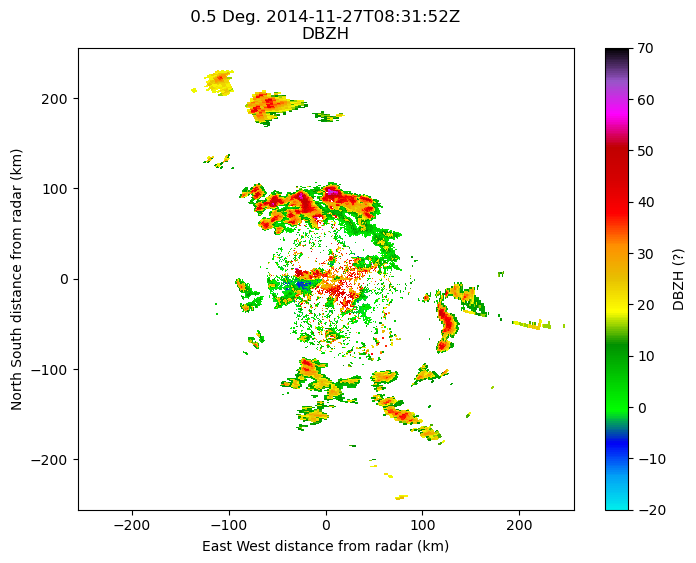

In [17]:
# download and extract a radar volume into memory without writing to disk and plot PPI of DBZH field

import io
import zipfile
import requests
import pyart
import matplotlib.pyplot as plt        
# download the zip file into memory
response = requests.get(request_url)
response.raise_for_status()
zip_data = io.BytesIO(response.content)
# extract the specified member file into memory
with zipfile.ZipFile(zip_data) as zf:
    with zf.open('50_20141127_083152.pvol.h5') as member:
        radar_data = pyart.aux_io.read_odim_h5(member, file_field_names=True)
# plot PPI of DBZH field
fig = plt.figure(figsize=(8, 6))
display = pyart.graph.RadarDisplay(radar_data)
display.plot_ppi('DBZH', sweep=0, vmin=-20, vmax=70, cmap='NWSRef')
plt.show()

# no radar data was written to disk!
# this is especially useful on gadi where disk latency can be high but memory is plentiful and very fast!


### Final comments

AURA level 1b and level 2 data is updated once per year - this process requires about 2000 jobs using approximately 1.5 MSU.

To accelerate this task, we unzip load level 1 radar data into memory, and run parallel processing (using pebble). Writting level 1b and level 2 onto disk (/g/data/) is the main bottle neck and requires carefully management to prevent disk errors.

Selectively unzipping data from volumes into memory is great way to improve the performance of your code!